In [1]:
!pip install gensim
import pandas as pd
from gensim.models import Word2Vec
import numpy as np
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.8 MB/s eta 0:00:00


In [2]:
df=pd.read_csv('/content/Preprocessed_DonorsChoose_dataset.csv')

In [3]:
df.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0.0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0.0
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0.0
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0.0
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0.0


In [4]:
df['project_is_approved'].value_counts()

,count
project_is_approved,
1,713
0,147


In [5]:
X = df.drop(columns=['project_is_approved'])
y = df['project_is_approved']

# Convert all columns to string and concatenate row-wise
df['combined_text'] = X.astype(str).agg(' '.join, axis=1)

df[['combined_text', 'project_is_approved']].head()

,combined_text,project_is_approved
0,p253737 mrs in grades_prek_2 literacy_language...,0
1,p258326 mr fl grades_6_8 history_civics_health...,1
2,p182444 ms az grades_6_8 health_sports health_...,0
3,p246581 mrs ky grades_prek_2 literacy_language...,1
4,p104768 mrs tx grades_prek_2 math_science math...,1


In [6]:
import pandas as pd
import string
import re
import nltk
from collections import Counter

# Run once
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab') # Add this line

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text, return_string=False):

    if pd.isna(text):
        return "" if return_string else []

    # 1️⃣ Strip whitespace
    text = text.strip()

    # 2️⃣ Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # 3️⃣ Convert to lowercase
    text = text.lower()

    # 4️⃣ Remove numbers
    text = re.sub(r'\d+', '', text)

    # 5️⃣ Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 6️⃣ Remove special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 7️⃣ Tokenize
    tokens = nltk.word_tokenize(text)

    # 8️⃣ Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 9️⃣ Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    if return_string:
        return " ".join(tokens)  # For TF-IDF / BOW

    return tokens  # For Word2Vec / Deep Learning

    # df['processed_text'] = df['combined_text'].apply(preprocess_text)
    # df.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [7]:
# df['processed_text'] = df['combined_text'].apply(preprocess_text)
# df.head()

In [8]:
df['processed_text'] = df['combined_text'].apply(preprocess_text)
df.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary,combined_text,processed_text
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0.0,p253737 mrs in grades_prek_2 literacy_language...,"[p, mr, gradesprek, literacylanguage, eslliter..."
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0.0,p258326 mr fl grades_6_8 history_civics_health...,"[p, mr, fl, grade, historycivicshealthsports, ..."
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0.0,p182444 ms az grades_6_8 health_sports health_...,"[p, m, az, grade, healthsports, healthwellness..."
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0.0,p246581 mrs ky grades_prek_2 literacy_language...,"[p, mr, ky, gradesprek, literacylanguagemathsc..."
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0.0,p104768 mrs tx grades_prek_2 math_science math...,"[p, mr, tx, gradesprek, mathscience, mathemati..."


In [9]:
# Flatten all tokens
all_tokens = [token for tokens in df['processed_text'] for token in tokens]

freq = Counter(all_tokens)

# Remove words appearing less than 2 times
df['processed_text'] = df['processed_text'].apply(
    lambda tokens: [word for word in tokens if freq[word] >= 2]
)

In [20]:
df.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary,combined_text,processed_text,processed_text_str
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0.0,p253737 mrs in grades_prek_2 literacy_language...,"[p, mr, gradesprek, literacylanguage, eslliter...",p mr gradesprek literacylanguage eslliteracy e...
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0.0,p258326 mr fl grades_6_8 history_civics_health...,"[p, mr, fl, grade, wanted, projector, hungry, ...",p mr fl grade wanted projector hungry learner ...
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0.0,p182444 ms az grades_6_8 health_sports health_...,"[p, m, az, grade, healthsports, healthwellness...",p m az grade healthsports healthwellnessteamsp...
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0.0,p246581 mrs ky grades_prek_2 literacy_language...,"[p, mr, ky, gradesprek, literacylanguagemathsc...",p mr ky gradesprek literacylanguagemathscience...
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0.0,p104768 mrs tx grades_prek_2 math_science math...,"[p, mr, tx, gradesprek, mathscience, mathemati...",p mr tx gradesprek mathscience mathematics int...


In [11]:
df['processed_text_str'] = df['processed_text'].apply(lambda x: " ".join(x))

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_uni = TfidfVectorizer(ngram_range=(1,1), max_features=5000)
X_uni = tfidf_uni.fit_transform(df['processed_text_str'])

In [13]:
# tfidf_bi = TfidfVectorizer(ngram_range=(1,2), max_features=7000)
# X_bi = tfidf_bi.fit_transform(df['processed_text_str'])

In [14]:
# tfidf_tri = TfidfVectorizer(ngram_range=(1,3), max_features=10000)
# X_tri = tfidf_tri.fit_transform(df['processed_text_str'])

In [15]:
import gensim.downloader as api

word2vec_model = api.load("word2vec-google-news-300")
# 300 dimensional embeddings

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [16]:
import numpy as np

def document_embedding(tokens, model):
    vectors = []
    for word in tokens:
        if word in model:
            vectors.append(model[word])
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_w2v_avg = np.array([
    document_embedding(tokens, word2vec_model)
    for tokens in df['processed_text']
])

In [17]:
tfidf = TfidfVectorizer()
tfidf.fit(df['processed_text_str'])

tfidf_dict = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

In [18]:
# def weighted_embedding(tokens, model, tfidf_dict):
#     vectors = []
#     weights = []

#     for word in tokens:
#         if word in model and word in tfidf_dict:
#             vectors.append(model[word])
#             weights.append(tfidf_dict[word])

#     if len(vectors) == 0:
#         return np.zeros(model.vector_size)

#     vectors = np.array(vectors)
#     weights = np.array(weights)

#     return np.average(vectors, axis=0, weights=weights)

# X_w2v_weighted = np.array([
#     weighted_embedding(tokens, word2vec_model, tfidf_dict)
#     for tokens in df['processed_text']
# ])

In [21]:
X = X_uni   # or X_bi / X_tri / X_w2v_avg
y = df['project_is_approved']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(max_iter=500)
scores = cross_val_score(lr, X_train, y_train, cv=5)

print("LR CV Accuracy:", scores.mean())

LR CV Accuracy: 0.8284988892415106


In [26]:
svm = SVC()
scores = cross_val_score(svm, X_train, y_train, cv=5)

print("SVM CV Accuracy:", scores.mean())

SVM CV Accuracy: 0.8284988892415106


In [27]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

----- Logistic Regression -----
Accuracy: 0.8313953488372093

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        29
           1       0.83      1.00      0.91       143

    accuracy                           0.83       172
   macro avg       0.42      0.50      0.45       172
weighted avg       0.69      0.83      0.75       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


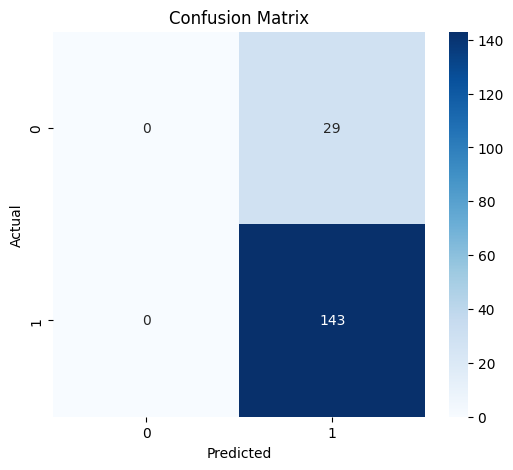

----- SVM -----
Accuracy: 0.8313953488372093

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        29
           1       0.83      1.00      0.91       143

    accuracy                           0.83       172
   macro avg       0.42      0.50      0.45       172
weighted avg       0.69      0.83      0.75       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


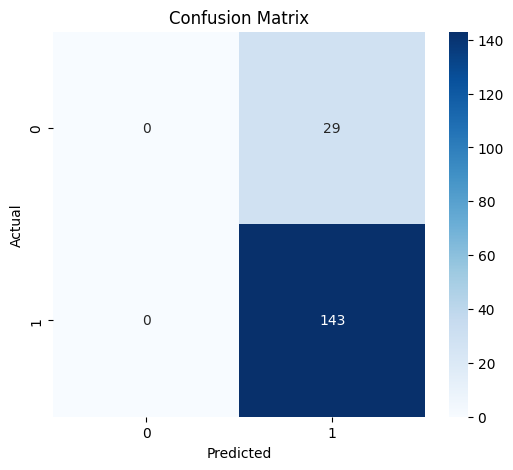

In [28]:
print("----- Logistic Regression -----")
evaluate_model(best_lr, X_test, y_test)

print("----- SVM -----")
evaluate_model(best_svm, X_test, y_test)

In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# For Logistic Regression
y_scores = best_lr.predict_proba(X_test)[:, 1]

# For SVM (must enable probability=True when creating model)
# svm = SVC(probability=True)
# y_scores = best_svm.predict_proba(X_test)[:, 1]

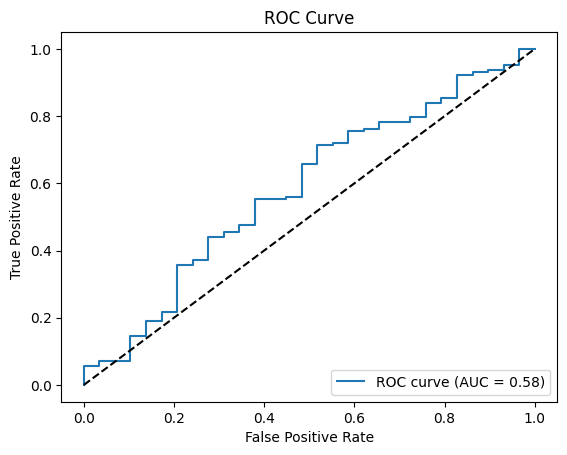

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()